In [1]:
import numpy as np
import scipy.io
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import mrestimator as mre
import h5py
import sys
sys.path.insert(0,'../experiment_analysis/ana/')

from hdestimator import utils as utl

import os

In [ ]:
# Import the data

mat = scipy.io.loadmat('SPP2205.mat')
df = pd.read_excel('SPP2205.xlsx') # same data as 'SPP2205.mat'but in excel format. -> Use for extraction the region information

# trying to figure out which column is what
n_id = 1
spikes = mat["data"][0][n_id][0]
status = mat["data"][0][n_id][2][0]
readout_n_id = mat["data"][0][n_id][3] # maybe?

# create a dict for every neuron
data = dict()
raw_data = mat["data"][0]


data[n_id] = dict()
for n_id in range(0, len(raw_data)):
    data[n_id] = dict()
    data[n_id]["spike_times"] = raw_data[n_id][0].flatten()
    data[n_id]["region"] = raw_data[n_id][1][0]
    data[n_id]["status"] = raw_data[n_id][2][0]
    data[n_id]["clusterID"] = raw_data[n_id][3][0,0]
    data[n_id]["channel"] = raw_data[n_id][4][0,0]
    data[n_id]["region"] = df.loc[n_id, "region"]

# Further metrics
bin_size = 5E-3 # bin size 5 ms

for n_id in range(0, len(raw_data)):
    data[n_id]['binned_spikes'] = utl.get_binned_neuron_activity(data[n_id]["spike_times"], bin_size) 
    data[n_id]['firing_rate'] = utl.get_binned_firing_rate(data[n_id]["spike_times"], bin_size) 

spike_times = [data[id]["spike_times"] for id in range(len(data))]

In [14]:

df = pd.DataFrame.from_dict(data, orient="index")
df

,spike_times,region,status,clusterID,channel,binned_spikes,firing_rate
1,"[0.050633333333333336, 0.20113333333333333, 0....",NI_MVL,good,3,28,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, ...",17.757871
0,"[0.0255, 0.09143333333333334, 0.12373333333333...",NI_MVL,mua,1,12,"[0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",26.548263
2,"[6.8444, 8.2997, 8.620166666666666, 12.2557666...",NI_MVL,good,4,75,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.264246
3,"[0.48906666666666665, 1.6315666666666666, 9.42...",NI_MVL,good,6,63,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.318359
4,"[0.029733333333333334, 0.0391, 0.0499, 0.06203...",NI_MVL,good,7,47,"[0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, ...",15.924023
...,...,...,...,...,...,...,...
231,"[2.3494333333333333, 7.925433333333333, 8.7704...",NI_MVL,good,509,250,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.629206
232,"[0.26443333333333335, 0.7258333333333333, 1.30...",NI_MVL,good,516,154,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",4.560378
233,"[4.6534, 4.956, 5.213533333333333, 5.61, 9.615...",NI_MVL,mua,517,154,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.507486
234,"[0.8188, 1.2559666666666667, 1.261966666666666...",NI_MVL,good,540,215,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0.846011


In [37]:
print(f"NI/MVL:     " , df.query("region == 'NI_MVL'").loc[:,'firing_rate'].mean(), "+/-", df.query("region == 'NI_MVL'").loc[:,'firing_rate'].median())
print(f"Entopallium:" , df.query("region == 'entopallium'").loc[:,'firing_rate'].mean(), "+/-", df.query("region == 'entopallium'").loc[:,'firing_rate'].median())

NI/MVL:      14.151258496224425 +/- 5.683788475323617
Entopallium: 12.146371428815259 +/- 4.710586441532672


analysis: 0002, hde v. 0.10b2, 2025-02-26
100.0
recording length: 1166.4s
recording length sd: 0.0s
firing rate: 4.7Hz
firing rate sd: 0.0Hz

Shuffling
---------------------------------------------------------------
T_D [s]: 0.040
tau_R [s]: 0.004
R_tot: 0.095
R_tot, 95% CI: [nan, nan]
opt. d: 5
opt. kappa: 0.091
opt. tau_1 [s]: 0.005

BBC
---------------------------------------------------------------
T_D [s]: 0.040
tau_R [s]: 0.004
R_tot: 0.094
R_tot, 95% CI: [nan, nan]
opt. d: 5
opt. kappa: 0.091
opt. tau_1 [s]: 0.005
Saved image to ./analysis/ANALYSIS0002/0002.pdf


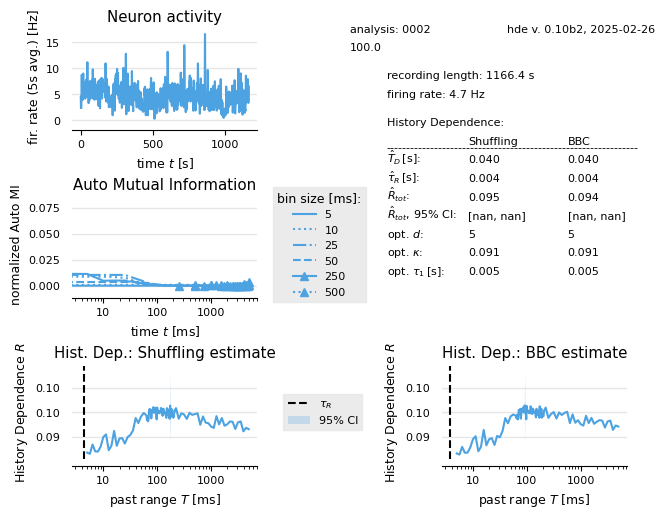

In [55]:
from estimate import hde_estimate_main

unit_id = 100
spiketimes = spike_times[unit_id]
filename = f'./hde_spikefile_{unit_id:04d}'

arguments =[
    filename,
     '--persistent',
     '--settings-file', './hdestimator_settings.yaml', 
     '--analysis_dir', './analysis',
     '--hdf5-dataset', '/spiketimes', 
     '--estimation_method', 'all',
     '--label', str(unit_id),
]



with h5py.File(filename, 'w') as f:
        f.create_dataset("/spiketimes", data=spiketimes)
        hde_estimate_main(arguments)

os.remove(filename)

In [53]:
f =  h5py.File('./analysis/ANALYSIS0000/analysis_data.h5', 'r')
print(f.keys())
print(f['other'].keys())
f['other/recording_length_sd']

<KeysViewHDF5 ['auto_MI', 'embeddings', 'other']>
<KeysViewHDF5 ['H_spiking', 'firing_rate', 'firing_rate_sd', 'recording_length', 'recording_length_sd']>


<HDF5 dataset "recording_length_sd": shape (), type "<f8">

analysis: 0000, hde v. 0.10b2, 2025-02-26
pid_35977
recording length: 1166.5s
recording length sd: 0.0s
firing rate: 17.8Hz
firing rate sd: 0.0Hz

Shuffling
---------------------------------------------------------------
T_D [s]: 0.035
tau_R [s]: 0.007
R_tot: 0.009
R_tot, 95% CI: [nan, nan]
opt. d: 5
opt. kappa: 0.070
opt. tau_1 [s]: 0.005

BBC
---------------------------------------------------------------
T_D [s]: 0.056
tau_R [s]: 0.007
R_tot: 0.009
R_tot, 95% CI: [nan, nan]
opt. d: 5
opt. kappa: 0.150
opt. tau_1 [s]: 0.005
Saved image to /tmp/hde_analysis_cidbn300_35977_0016e4b6b4c7bm1n81wx/ANALYSIS0000/0000.pdf


FileNotFoundError: [Errno 2] No such file or directory: './analysis//statistics_.csv'

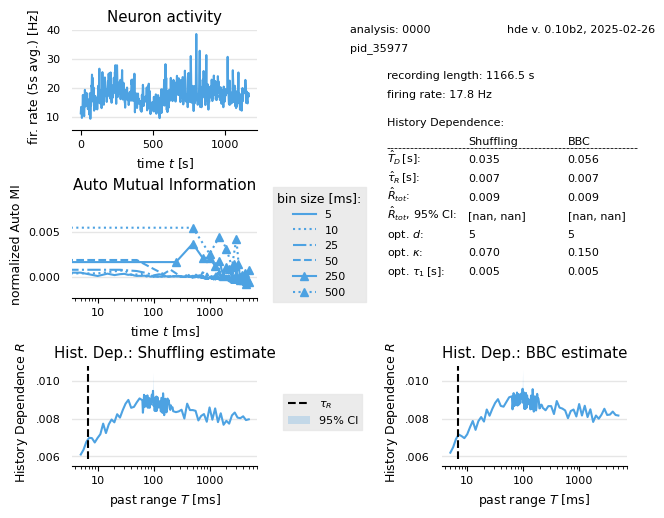

In [3]:
from hdestimator_wrapper_mr import hde
args = {}
args['estimation_method'] = 'all'
#args["analysis_dir"] = '/home/marcelraabe/miniforge3/envs/mouse_visual_timescales/pigeon_data/analysis/'


res = hde(spike_times[1]  , cli_args=args)

In [5]:
res

{'tau_R_bbc': 0.00697,
 'T_D_bbc': 0.0561,
 'R_tot_bbc': 0.00915,
 'R_tot_bbc_CI_lo': '-',
 'R_tot_bbc_CI_hi': '-',
 'AIS_tot_bbc': 0.00274,
 'AIS_tot_bbc_CI_lo': '-',
 'AIS_tot_bbc_CI_hi': '-',
 'opt_number_of_bins_d_bbc': 5.0,
 'opt_scaling_k_bbc': 0.15019,
 'opt_first_bin_size_bbc': 0.005,
 'tau_R_shuffling': 0.00746,
 'T_D_shuffling': 0.0561,
 'R_tot_shuffling': 0.00908,
 'R_tot_shuffling_CI_lo': '-',
 'R_tot_shuffling_CI_hi': '-',
 'AIS_tot_shuffling': 0.00272,
 'AIS_tot_shuffling_CI_lo': '-',
 'AIS_tot_shuffling_CI_hi': '-',
 'opt_number_of_bins_d_shuffling': 5.0,
 'opt_scaling_k_shuffling': 0.15019,
 'opt_first_bin_size_shuffling': 0.005,
 'embedding_step_size': 0.005,
 'bbc_tolerance': 0.05,
 'timescale_minimum_past_range': 0.0,
 'number_of_bootstraps_bbc': '-',
 'number_of_bootstraps_shuffling': '-',
 'bs_CI_percentile_lo': 2.5,
 'bs_CI_percentile_hi': 97.5,
 'firing_rate': 17.75092,
 'firing_rate_sd': 0.0,
 'recording_length': 1166.4706,
 'recording_length_sd': 0.0,
 'H_spiki

plt.figure(figsize=(30,15))
for i, data in enumerate(spike_times):
    if data[i]["status"] == 'good': color='g'
    else: color='r'
    plt.scatter(data, np.ones_like(data)*i, marker='|', color=color, alpha=.5)


plt.xlabel('time (s)')
plt.ylabel('unit')
plt.xlim(0,50)
plt.ylim(0,236)
plt.title("Activity")

red_patch = mpl.patches.Patch(color='red', label='#multi unit=81')
green_patch = mpl.patches.Patch(color='g', label='#good=155')
plt.legend(title="status", handles=[green_patch, red_patch])

Text(0, 0.5, '#spikes')

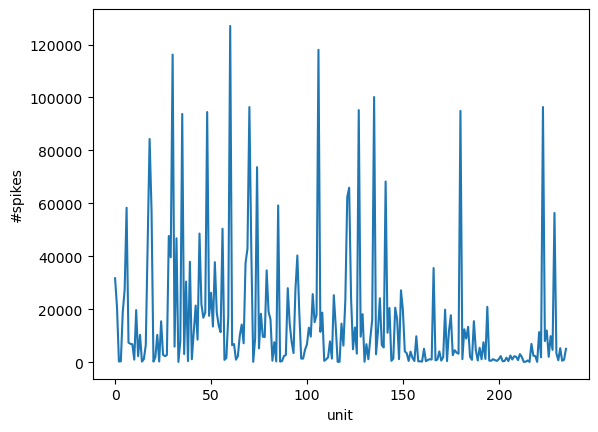

In [ ]:
# Check number of entries per unit
plt.plot([len(arr) for arr in spike_times])
plt.xlabel("unit")
plt.ylabel("#spikes")

Text(0, 0.5, '#NaN')

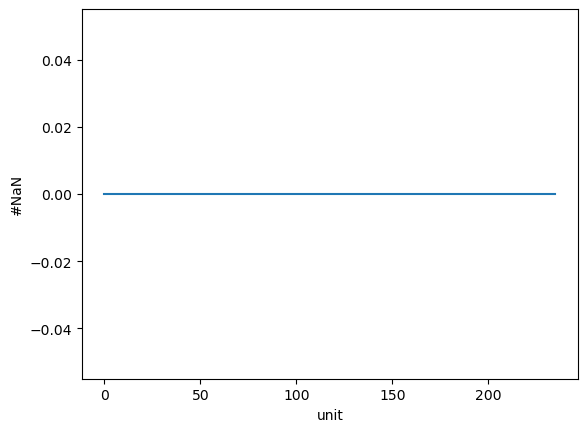

In [ ]:
# Check for NaNs
plt.plot([sum(np.isnan(arr)) for arr in spike_times])
plt.xlabel("unit")
plt.ylabel("#NaN")

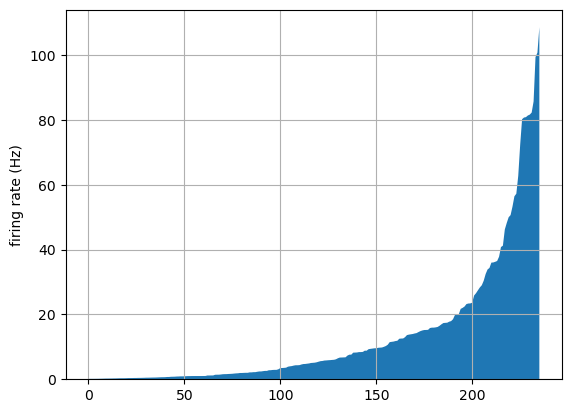

In [ ]:
firing_rates = [utl.get_binned_firing_rate(train, bin_size) for train in spike_times]
firing_rates = sorted(firing_rates)

plt.fill_between(np.arange(len(firing_rates)), firing_rates)
plt.ylabel("firing rate (Hz)")
plt.ylim(0)
plt.grid()

In [ ]:
%load_ext autoreload
%autoreload 2

>>> shuffling
analysis: 0001, hde v. 0.10b2, 2025-02-24
pid_24476
recording length: 1166.5s
recording length sd: 0.0s
firing rate: 17.8Hz
firing rate sd: 0.0Hz

Shuffling
---------------------------------------------------------------
T_D [s]: 0.056
tau_R [s]: 0.007
R_tot: 0.009
R_tot, 95% CI: [nan, nan]
opt. d: 5
opt. kappa: 0.150
opt. tau_1 [s]: 0.005

BBC
---------------------------------------------------------------
T_D [s]: nan
tau_R [s]: nan
R_tot: nan
R_tot, 95% CI: [nan, nan]
opt. d: nan
opt. kappa: nan
opt. tau_1 [s]: nan
Saved image to ./analysis/ANALYSIS0001/0001.pdf


KeyError: 'analysis_dir'

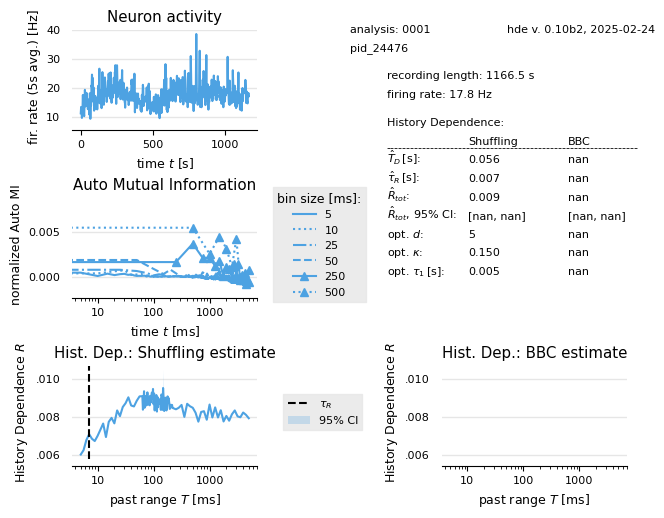

In [ ]:
print(args)

{'estimation_method': 'bbc'}
